In [ ]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    import torch; v = re.match(r"[0-9]{1,}\.[0-9]{1,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.33.post1" if v=="2.9" else "0.0.32.post2" if v=="2.8" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.57.1
!pip install --no-deps trl==0.22.2

In [ ]:
# !pip show unsloth xformers bitsandbytes

In [ ]:
from unsloth import FastVisionModel
import torch
model , tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3-VL-8B-Instruct-unsloth-bnb-4bit" ,
    load_in_4bit = True ,
    use_gradient_checkpointing = "unsloth"
)

==((====))==  Unsloth 2025.12.9: Fast Qwen3_Vl patching. Transformers: 4.57.1.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 7.5. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.72G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/817 [00:00<?, ?B/s]

In [ ]:
model = FastVisionModel.get_peft_model(
    model ,
    finetune_vision_layer = True ,
    finetune_language_layer = True ,
    finetune_attention_modules = True ,
    finetune_mlp_modules = False ,

    r = 16 , ## if more then higher the accuracy but might overfit
    lora_alpha = 16 ,   # keep alpha == r
    lora_dropout = 0 ,
    bias = "none" ,
    random_state = 3407 ,
    use_rslora=False ,
    loftq_config = None
)

In [ ]:
## load the dataset
from datasets import load_dataset
dataset = load_dataset("unsloth/RLAIF-V-Dataset" , split ="train")


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/376M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2493 [00:00<?, ? examples/s]

In [ ]:
dataset

Dataset({
    features: ['image', 'question', 'answer'],
    num_rows: 2493
})

In what state are these mountain ranges? 
 The image shows a crossroad sign featuring names of places, including "Dyrgas Gate" and "Fitzgerald", with mountains in the background. These signs are often found in areas with diverse geographical features, suggesting that the location could be in a state with mountainous landscapes. Without more specific details or context, it's challenging to determine the exact state where these mountain ranges are located. However, such landscapes can be found in various states across the United States, each offering its own unique beauty and attractions.


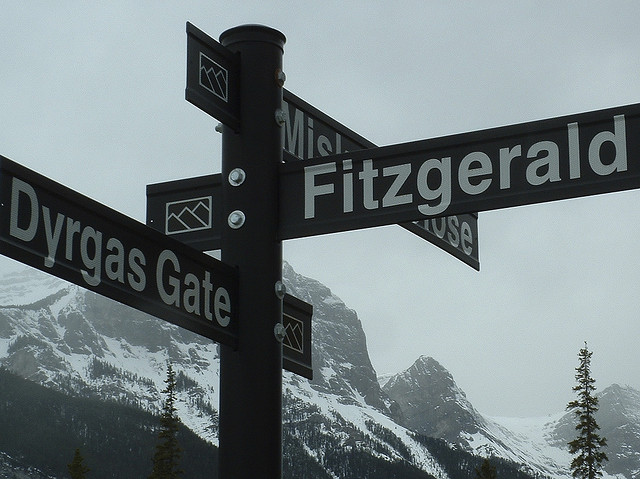

In [ ]:
ind = 10
print(dataset[ind]['question'] ,"\n", dataset[ind]['answer'])
dataset[ind]['image']

In [ ]:
dataset

Dataset({
    features: ['image', 'question', 'answer'],
    num_rows: 2493
})

In [ ]:

def convert_to_conversation(sample):
    conversation = [
        { "role": "user",
          "content" : [
            {"type" : "question",  "text"  : sample["question"]},
            {"type" : "image", "image" : sample["image"]}]
        },
        { "role" : "assistant",
          "content" : [
            {"type" : "text",  "text"  : sample["answer"]} ]
        },
    ]
    return { "messages" : conversation }
pass

In [ ]:
converted_dataset = [convert_to_conversation(sample) for sample in dataset]

In [ ]:
converted_dataset[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'question', 'text': 'What color is the wall?'},
    {'type': 'image',
     'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x427>}]},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': 'The wall in the background of the image is painted in a solid, warm red color. The exact shade may vary depending on the lighting conditions and the specific color reproduction of the image, but it appears to be a deep, rich red.'}]}]}

In [ ]:
FastVisionModel.for_inference(model) # Enable for inference!

ind = 10
question = dataset[ind]['question']
print(f"expected answer : {dataset[ind]['answer']}")
image = dataset[ind]['image']

messages = [
    {"role": "user", "content": [
        {"type": "question" , "text":question},
        {"type": "image", "image": image}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
res = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)
print(res)

expected answer : The image shows a crossroad sign featuring names of places, including "Dyrgas Gate" and "Fitzgerald", with mountains in the background. These signs are often found in areas with diverse geographical features, suggesting that the location could be in a state with mountainous landscapes. Without more specific details or context, it's challenging to determine the exact state where these mountain ranges are located. However, such landscapes can be found in various states across the United States, each offering its own unique beauty and attractions.
Based on the road signs and the mountainous background, the location shown in the image is in **Colorado**.

Here's why:

- The signs point to **"Fitzgerald"** and **"Dyrgas Gate"**.
- "Dyrgas Gate" is a known trailhead or junction near **Grand Junction, Colorado**, on the **Grand Mesa**.
- "Fitzgerald" refers to the **Fitzgerald Pass** or nearby areas on the **Uncompahgre National Forest** in Colorado.
- The mountains visible 

In [ ]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model) # Enable for training!

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer), # Must use!
    train_dataset = converted_dataset,
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        # num_train_epochs = 1, # Set this instead of max_steps for full training runs
        max_steps= 30 ,
        learning_rate = 2e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",     # For Weights and Biases

        # You MUST put the below items for vision finetuning:
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    ),
)

Unsloth: Model does not have a default image size - using 512


In [ ]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.741 GB.
8.113 GB of memory reserved.


In [ ]:
trainer_stats = trainer.train()

The model is already on multiple devices. Skipping the move to device specified in `args`.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,493 | Num Epochs = 1 | Total steps = 30
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 18,321,408 of 8,785,445,104 (0.21% trained)


Step,Training Loss
1,0.849400
2,0.982900
3,0.775300
4,0.896500
5,0.866400
6,0.855600
7,0.883000
8,0.901100
9,0.849600
10,0.848400


In [ ]:
SAVE_DIR = "finetuned_vision_model"

model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)


[]

In [ ]:
from huggingface_hub import login
login("YOUR_HUGGINGFACE_TOKEN")

In [ ]:
model.push_to_hub("Rohit-Katkar2003/qwen2-vl-8b-lora-finetune")
tokenizer.push_to_hub("Rohit-Katkar2003/qwen2-vl-8b-lora-finetune")


README.md:   0%|          | 0.00/594 [00:00<?, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Saved model to https://huggingface.co/Rohit-Katkar2003/qwen2-vl-8b-lora-finetune


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

In [ ]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

310.6525 seconds used for training.
5.18 minutes used for training.
Peak reserved memory = 8.15 GB.
Peak reserved memory for training = 0.037 GB.
Peak reserved memory % of max memory = 55.288 %.
Peak reserved memory for training % of max memory = 0.251 %.


In [ ]:
dataset[10]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x479>,
 'question': 'In what state are these mountain ranges?',
 'answer': 'The image shows a crossroad sign featuring names of places, including "Dyrgas Gate" and "Fitzgerald", with mountains in the background. These signs are often found in areas with diverse geographical features, suggesting that the location could be in a state with mountainous landscapes. Without more specific details or context, it\'s challenging to determine the exact state where these mountain ranges are located. However, such landscapes can be found in various states across the United States, each offering its own unique beauty and attractions.'}

In [ ]:
FastVisionModel.for_inference(model) # Enable for inference!
ind = 10
image = dataset[ind]["image"]
question = "what is witten on board all words in image"
print(f"actual answer : {dataset[ind]['answer']}")
print("=="*30)
messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": question}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

actual answer : The image shows a crossroad sign featuring names of places, including "Dyrgas Gate" and "Fitzgerald", with mountains in the background. These signs are often found in areas with diverse geographical features, suggesting that the location could be in a state with mountainous landscapes. Without more specific details or context, it's challenging to determine the exact state where these mountain ranges are located. However, such landscapes can be found in various states across the United States, each offering its own unique beauty and attractions.
the words in the image include "dyrgas gate" and "fitzgerald." the signs appear to be road signs, providing directions or names related to locations. The presence of these signs suggests that they are placed along routes, possibly guiding drivers or travelers to specific places or landmarks.<|im_end|>


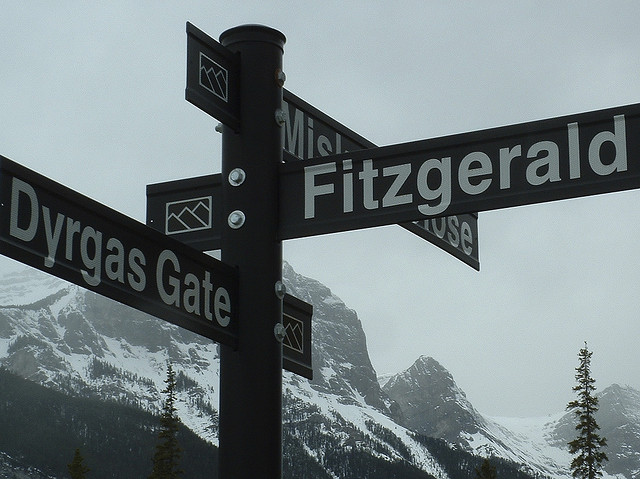

In [ ]:
image

In [ ]:
## load the model from my own huggingface
from unsloth import FastVisionModel

model, tokenizer = FastVisionModel.from_pretrained(
    "Rohit-Katkar2003/qwen2-vl-8b-lora-finetune",
    load_in_4bit=True
)


==((====))==  Unsloth 2025.12.9: Fast Qwen3_Vl patching. Transformers: 4.57.1.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 7.5. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

adapter_model.safetensors:   0%|          | 0.00/73.3M [00:00<?, ?B/s]

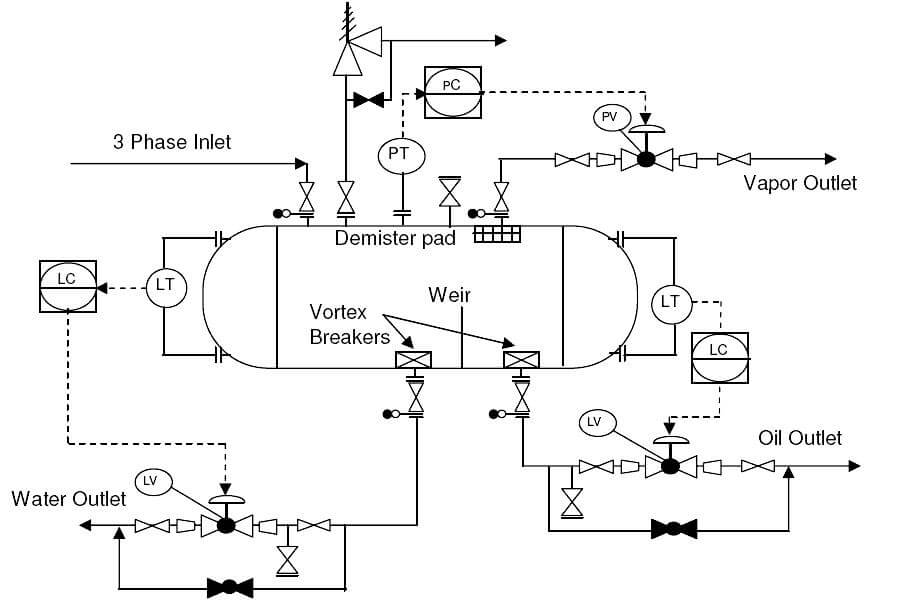

In [ ]:
from io import BytesIO
from PIL import Image
import requests
url = "https://instrumentationtools.com/wp-content/uploads/2016/09/instrumentationtools.com_piping-and-instrumentation-diagram.jpg"
res = requests.get(url)
img = Image.open(BytesIO(res.content))
img

In [ ]:
FastVisionModel.for_inference(model) # Enable for inference!
question = "what are the components in diagram give me response in markdown format with all the connection and components?"
url = "https://instrumentationtools.com/wp-content/uploads/2016/09/instrumentationtools.com_piping-and-instrumentation-diagram.jpg"
res = requests.get(url)
image = Image.open(BytesIO(res.content))
messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": question}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 1024,
                   use_cache = True, temperature = 0.3, min_p = 0.1)

# Diagram Components and Connections

## Main Components
- Demister pad
- Vortex Breakers
- Weir
- 3 Phase Inlet
- Vapor Outlet
- Water Outlet
- Oil Outlet

## Connections
- The demister pad is connected to the vortex breakers.
- The vortex breakers are connected to the weir.
- The weir is connected to the 3 phase inlet.
- The 3 phase inlet is connected to the vapor outlet.
- The vapor outlet is connected to the water outlet.
- The water outlet is connected to the oil outlet.<|im_end|>
